In [51]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import learning_curve
from tqdm import tqdm

from sklearn.datasets import load_files
from pyvi import ViTokenizer

from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay,make_scorer

%matplotlib inline

In [2]:
%cd D:/du_lieu_huan_luyen
os.listdir()


D:\du_lieu_huan_luyen


c:\Users\Admin\miniconda3\envs\haideptrai\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


['australian.dat',
 'batdongsan.csv',
 'Bengaru.csv',
 'cancer_data.csv',
 'data.csv',
 'data1.csv',
 'data2.csv',
 'german.data-numeric',
 'kc_house_data.csv',
 'Loan Modelling Thera Bank.csv',
 'news_vnexpress',
 'vietnamese-stopwords.txt']

In [16]:
data = load_files(container_path='news_vnexpress' , encoding= 'utf8')
data_train = data.data
data_target = data.target

In [17]:
with open('vietnamese-stopwords.txt', encoding='utf8') as f:
    stop_words = f.readlines()
stop_words = [x.strip().replace("","_") for x in stop_words]
model_count = TfidfVectorizer(encoding='utf_8', stop_words=stop_words)
data_train = model_count.fit_transform(data_train)
type(data_train)

scipy.sparse._csr.csr_matrix

In [ ]:
X_train,X_test,y_train,y_test = train_test_split (data_train,data_target,random_state=42,test_size=0.2)

<class 'scipy.sparse._csr.csr_matrix'> <class 'numpy.ndarray'>


In [ ]:
def cross_validation(estimator):
    _, train_scores, test_scores = learning_curve(estimator , X_train, y_train, cv=10, n_jobs=-1, train_sizes=[1.0, ], scoring="accuracy")
    test_scores = test_scores[0]
    mean, std = test_scores.mean(), test_scores.std()
    return mean, std
def plot(title, xlabel, X, Y, error, ylabel = "Accuracy"):
    
    plt.xlabel(xlabel)
    plt.grid()
    plt.ylabel(ylabel)
    plt.title(title)
    plt.errorbar(x = X, y = Y,linestyle = 'None',marker = 'o')
    plt.show()

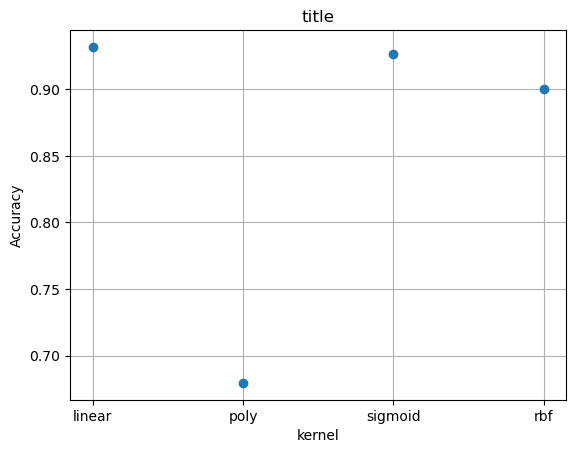

In [20]:
title = "thay đổi kernel, C = 1"
xlabel = "kernel"
X = []
Y = []
error = []
for kernel in ['linear','poly','sigmoid','rbf']:
    model = svm.SVC(C = 1.0 , kernel=kernel)
    mean,std  = cross_validation(model)
    X.append(kernel)
    Y.append(mean)
    error.append(std)
plot(title=title,xlabel=xlabel,X = X, Y = Y, error = error)

100%|██████████| 5/5 [00:28<00:00,  5.80s/it]


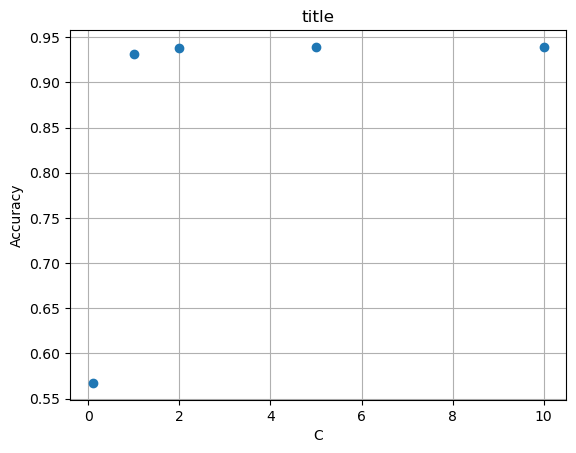

In [22]:
title = "thay đổi C, kernel = linear"
xlabel = "C"
X = []
Y = []
error = []
for C in tqdm([.1, 1.0, 2.0, 5.0, 10.0]):
    model = svm.SVC(C = C , kernel='linear')
    mean,std  = cross_validation(model)
    X.append(C)
    Y.append(mean)
    error.append(std)
plot(title=title,xlabel=xlabel,X = X, Y = Y, error = error)

100%|██████████| 3/3 [00:04<00:00,  1.53s/it]


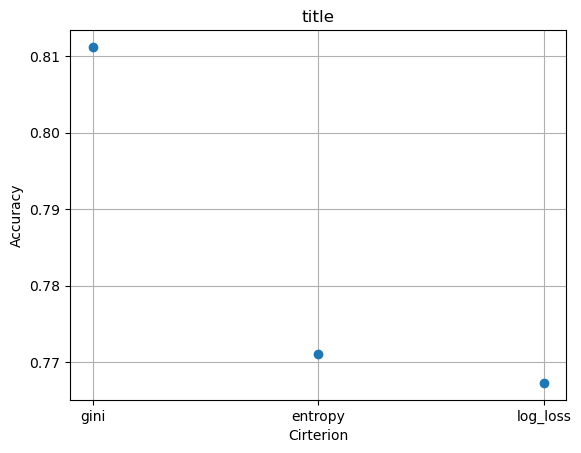

In [23]:
title = "thay đổi criterion, n_estimator = 50"
xlabel = "Cirterion"
X = []
Y = []
error = []
for criterion in tqdm(['gini', 'entropy', 'log_loss']):
    model = RandomForestClassifier(n_estimators=50,criterion= criterion)
    mean,std  = cross_validation(model)
    X.append(criterion)
    Y.append(mean)
    error.append(std)
plot(title=title,xlabel=xlabel,X = X, Y = Y, error = error)

100%|██████████| 4/4 [00:11<00:00,  2.76s/it]


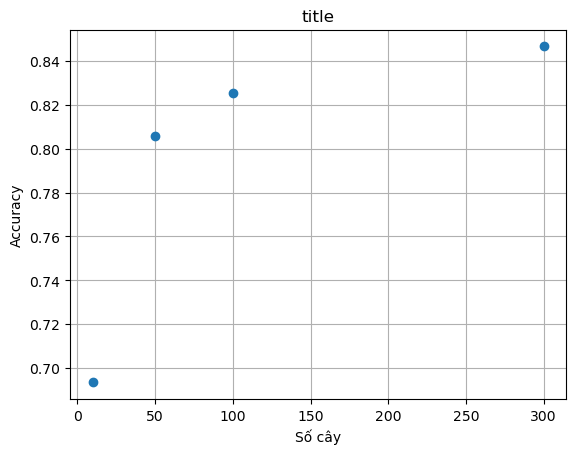

In [24]:
title = "thay đổi số cây, criterion = 'gini"
xlabel = "Số cây"
X = []
Y = []
error = []
for n_estimators in tqdm([10, 50, 100, 300]):
    model = RandomForestClassifier(n_estimators=n_estimators,criterion= 'gini')
    mean,std  = cross_validation(model)
    X.append(n_estimators)
    Y.append(mean)
    error.append(std)
plot(title=title,xlabel=xlabel,X = X, Y = Y, error = error)

100%|██████████| 6/6 [00:02<00:00,  2.39it/s]


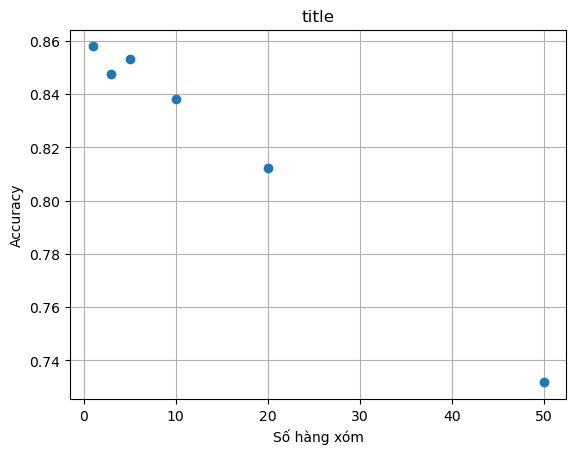

In [28]:
title = "thay đổi tham số k trong KNN, p = 2"
xlabel = "Số hàng xóm"
X = []
Y = []
error = []
for n_neighbours in tqdm([1, 3, 5, 10, 20, 50]):
    model = KNeighborsClassifier(n_neighbors= n_neighbours, metric='minkowski', p = 2)
    mean,std  = cross_validation(model)
    X.append(n_neighbours)
    Y.append(mean)
    error.append(std)
plot(title=title,xlabel=xlabel,X = X, Y = Y, error = error)

In [ ]:
svm_ = svm.SVC(kernel='linear', C = 5.0)
rf = RandomForestClassifier(criterion='gini', n_estimators=300)
knn = KNeighborsClassifier(n_neighbors=1)

# Huấn luyện các mô hình trên tập dữ liệu train đầy đủ
svm_.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train, y_train)

In [31]:
print(accuracy_score(y_test,svm_.predict(X_test)))
print(accuracy_score(y_test,rf.predict(X_test)))
print(accuracy_score(y_test,knn.predict(X_test)))

0.914179104477612
0.8544776119402985
0.8432835820895522


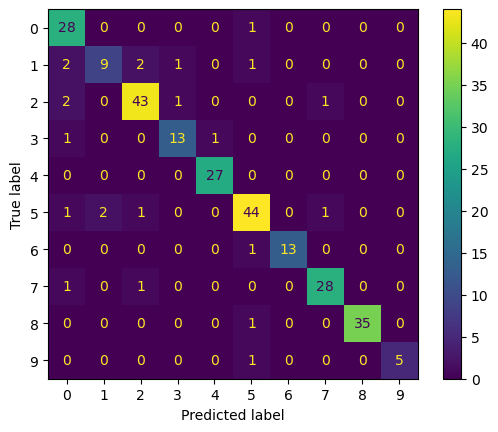

In [36]:
ConfusionMatrixDisplay.from_estimator(svm_, X_test, y_test)
plt.show()

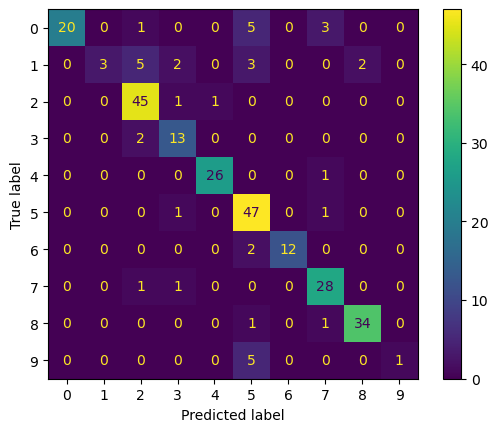

In [37]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.show()

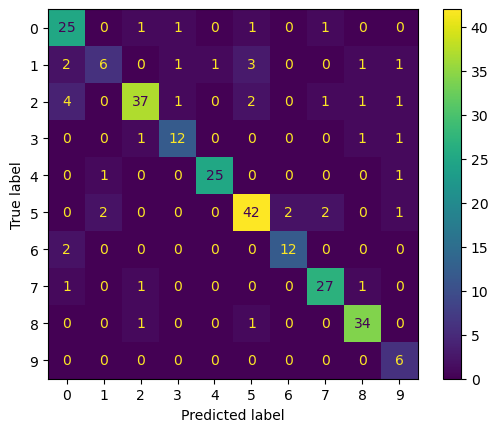

In [38]:
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
plt.show()

# 5. Bài tập
- Sử dụng dữ liệu đánh giá tín dụng cá nhân
- Sử dụng độ đo đánh giá negative cost
- Lựa chọn tham số cho các mô hình SVM, Random Forest và KNN
- So sánh các mô hình với siêu tham số tốt nhất 

In [49]:
data = np.genfromtxt('german.data-numeric')
X_train,X_test,y_train,y_test = train_test_split(data[:, :24], data[:, -1] ,test_size= 0.2, random_state= 42)


In [62]:
cost_matrix = np.array([[0,1], [5,0]])
def negative_cost(y_pred, y_true):
    true_pos = (((y_true==y_pred)&(y_true==1.0))*0.0) #Đoán đúng là đúng
    false_pos = (((y_true==y_pred)&(y_true==0.0))*0.0) #Đoán sai là sai
    true_neg = (((y_true !=y_pred)&(y_true==1.0))*1.0) #Đoán đúng là sai
    false_neg = (((y_true !=y_pred)&(y_true==0.0))*5.0) #Đoán sai là đúng
    return sum(true_neg + true_pos + false_pos + false_neg)/len(y_pred)
cost_scorer = make_scorer(negative_cost, greater_is_better=False)

In [65]:
def cross_validation(estimator,X,y):
    _, train_scores, test_scores = learning_curve(estimator , X=X,  y = y, cv=10, n_jobs=-1, train_sizes=[1.0, ], scoring= cost_scorer)
    test_scores = -test_scores[0]
    mean, std = test_scores.mean(), test_scores.std()
    return mean, std
def plot(title, xlabel, X, Y, error, ylabel = "Chi phí lỗi"):
    
    plt.xlabel(xlabel)
    plt.grid()
    plt.ylabel(ylabel)
    plt.title(title)
    plt.errorbar(x = X, y = Y,linestyle = 'None',marker = 'o',yerr=error,capsize=5)
    plt.show()

100%|██████████| 5/5 [00:10<00:00,  2.16s/it]


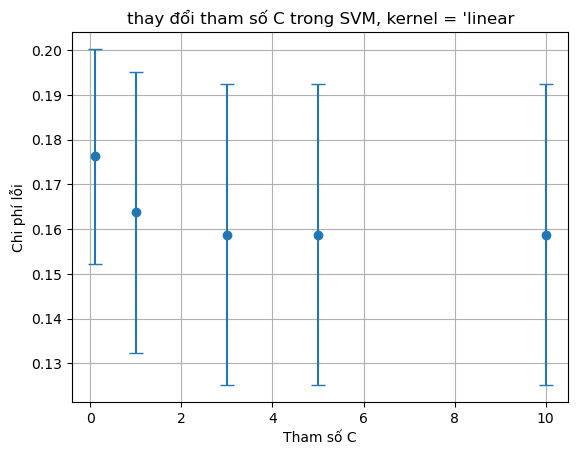

In [66]:
title = "thay đổi tham số C trong SVM, kernel = 'linear"
xlabel = "Tham số C"
X = []
Y = []
error = []
for C in tqdm([0.1,1.0, 3.0, 5.0, 10]):
    model = svm.SVC(C = C, kernel = 'linear')
    mean,std  = cross_validation(model,X_train,y_train)
    X.append(C)
    Y.append(mean)
    error.append(std)
plot(title=title,xlabel=xlabel,X = X, Y = Y, error = error)

100%|██████████| 4/4 [00:01<00:00,  2.00it/s]


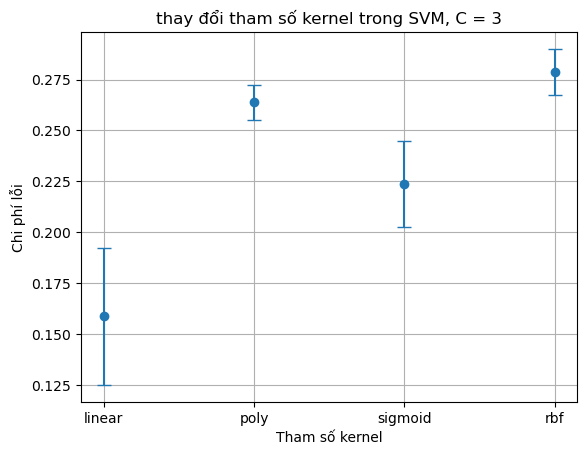

In [67]:
title = "thay đổi tham số kernel trong SVM, C = 3"
xlabel = "Tham số kernel"
X = []
Y = []
error = []
for kernel in tqdm(['linear','poly','sigmoid','rbf']):
    model = svm.SVC(C = 3.0, kernel = kernel)
    mean,std  = cross_validation(model,X_train,y_train)
    X.append(kernel)
    Y.append(mean)
    error.append(std)
plot(title=title,xlabel=xlabel,X = X, Y = Y, error = error)

100%|██████████| 6/6 [00:00<00:00, 22.50it/s]


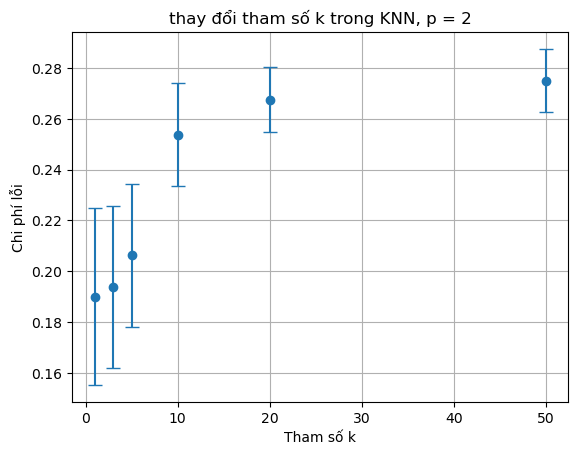

In [71]:
title = "thay đổi tham số k trong KNN, p = 2"
xlabel = "Tham số k"
X = []
Y = []
error = []
for n_neighbours in tqdm([1,3,5,10,20,50]):
    model = KNeighborsClassifier(n_neighbors=n_neighbours,p = 2)
    mean,std  = cross_validation(model,X_train,y_train)
    X.append(n_neighbours)
    Y.append(mean)
    error.append(std)
plot(title=title,xlabel=xlabel,X = X, Y = Y, error = error)

100%|██████████| 5/5 [00:01<00:00,  3.73it/s]


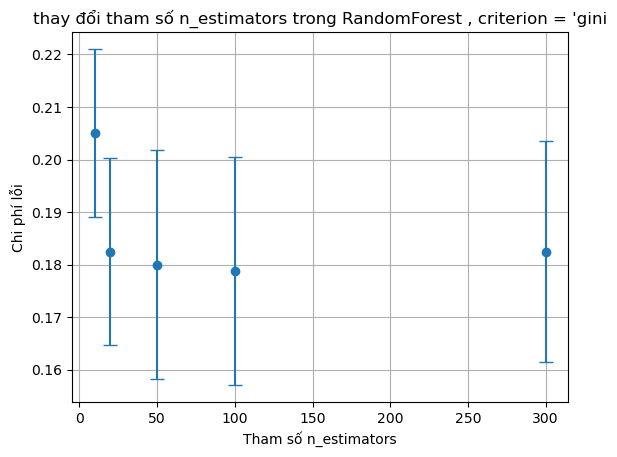

In [74]:
title = "thay đổi tham số n_estimators trong RandomForest , criterion = 'gini"
xlabel = "Tham số n_estimators"
X = []
Y = []
error = []
for n_estimators in tqdm([10,20,50, 100, 300]):
    model = RandomForestClassifier(n_estimators= n_estimators,criterion='gini')
    mean,std  = cross_validation(model,X_train,y_train)
    X.append(n_estimators)
    Y.append(mean)
    error.append(std)
plot(title=title,xlabel=xlabel,X = X, Y = Y, error = error)

100%|██████████| 3/3 [00:00<00:00,  3.31it/s]


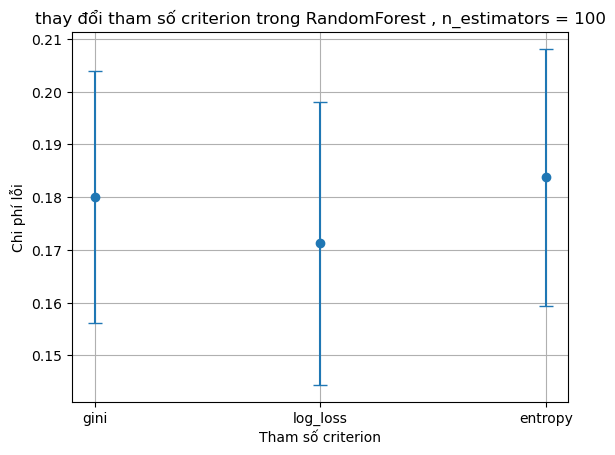

In [75]:
title = "thay đổi tham số criterion trong RandomForest , n_estimators = 100"
xlabel = "Tham số criterion"
X = []
Y = []
error = []
for criterion in tqdm(['gini','log_loss','entropy']):
    model = RandomForestClassifier(n_estimators= 100,criterion=criterion)
    mean,std  = cross_validation(model,X_train,y_train)
    X.append(criterion)
    Y.append(mean)
    error.append(std)
plot(title=title,xlabel=xlabel,X = X, Y = Y, error = error)

In [ ]:
svm_ = svm.SVC(C = 3, kernel= 'linear')
rf = RandomForestClassifier(n_estimators= 100,criterion= 'log_loss')
knn = KNeighborsClassifier(n_neighbors= 1, p = 2)

svm_.fit(X_train,y_train)
rf.fit(X_train,y_train)
knn.fit(X_train,y_train)


In [ ]:
print(f'Chi phí lỗi : {negative_cost(svm_.predict(y_test),y_test)}')
print(f'Chi phí lỗi : {negative_cost(rf.predict(y_test),y_test)}')
print(f'Chi phí lỗi : {negative_cost(knn.predict(y_test),y_test)}')